## Plotting xarray data

xarray is the standard Python library for labelled, multi-dimensional
arrays and is widely used for working with netCDF and other gridded
climate data.  earthkit-plots accepts xarray `DataArray` and `Dataset`
objects directly, with no conversion step required.

In [1]:
import earthkit.data as ekd

import earthkit.plots as ekp

### Loading data and converting to xarray

We start from the same ERA5 netCDF sample used in the other source-type
notebooks, then convert to an xarray Dataset with `.to_xarray()`.  This
is a common pattern when you want to do pre-processing (slicing,
arithmetic, resampling) before plotting.

In [2]:
nc = ekd.from_source("sample", "era5-monthly-mean-2t-199312.nc")
ds = nc.to_xarray()
ds

era5-monthly-mean-2t-199312.nc:   0%|          | 0.00/1.99M [00:00<?, ?B/s]

<xarray.Dataset> Size: 8MB
Dimensions:    (time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 8B 1993-12-01
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    t2m        (time, latitude, longitude) float64 8MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-05-21 15:58:02 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

### Plotting a Dataset

Pass the Dataset directly to any earthkit-plots method.  When the
Dataset contains a single variable earthkit-plots selects it
automatically; when there are multiple variables you will need to select
one (see below).

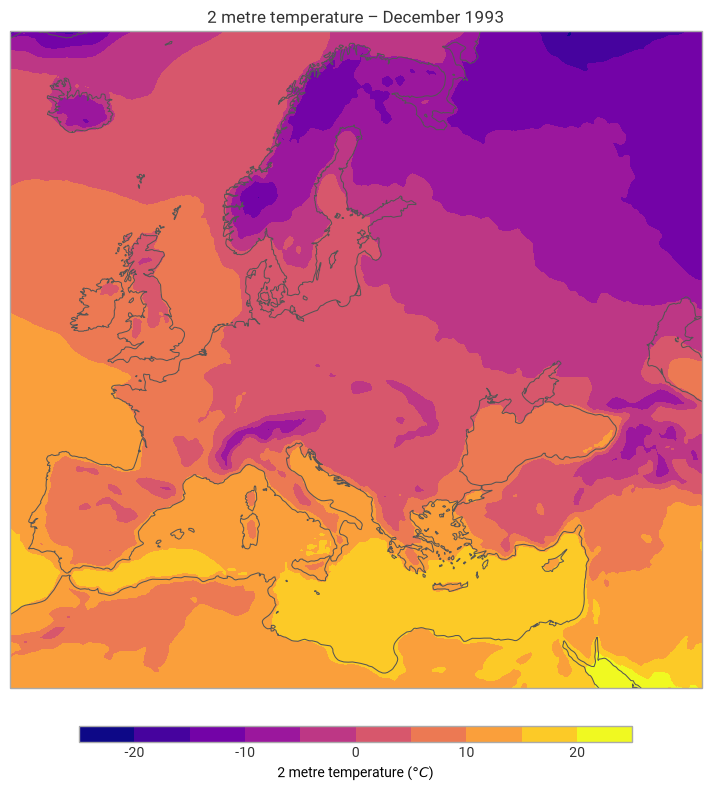

In [3]:
chart = ekp.Map(domain="Europe")
chart.contourf(ds, units="celsius")
chart.legend()
chart.coastlines()
chart.title("{variable_name} – {time:%B %Y}")
chart.show()

### Plotting a DataArray

You can also index into the Dataset and pass a single `DataArray`.  This
is useful when the Dataset contains multiple variables and you want to
be explicit about which one to plot.

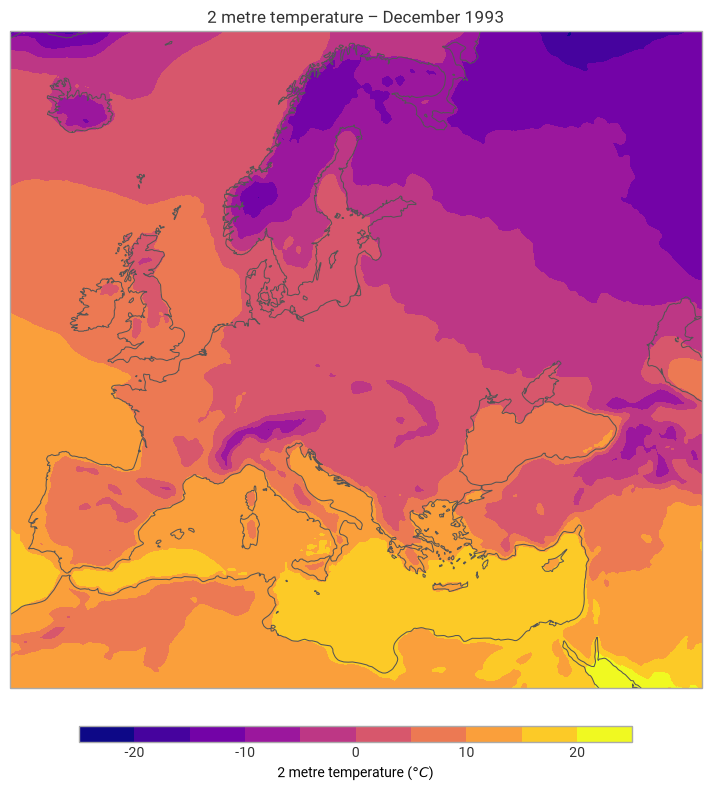

In [4]:
chart = ekp.Map(domain="Europe")
chart.contourf(ds["t2m"], units="celsius")
chart.legend()
chart.coastlines()
chart.title("{variable_name} – {time:%B %Y}")
chart.show()

### Automatic style selection

`plot()` reads the variable name and units from the xarray metadata and
selects an appropriate style automatically — exactly as it does for GRIB
and netCDF sources.

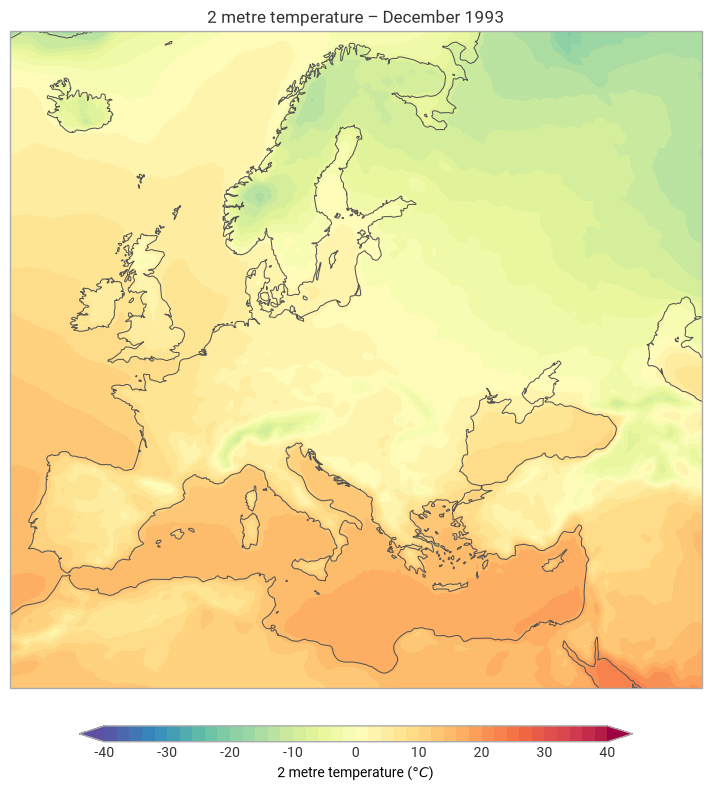

In [5]:
chart = ekp.Map(domain="Europe")
chart.plot(ds, units="celsius")
chart.legend()
chart.coastlines()
chart.title("{variable_name} – {time:%B %Y}")
chart.show()

### Format agnosticism

The code above is almost identical to the GRIB and netCDF examples —
the only difference is how the data object is created.  Once you have
any earthkit-data object, xarray Dataset, or xarray DataArray, the
plotting calls are the same:

```python
# GRIB
data = ekd.from_source("sample", "era5-monthly-mean-2t-199312.grib")

# netCDF
data = ekd.from_source("sample", "era5-monthly-mean-2t-199312.nc")

# xarray
data = ekd.from_source("sample", "era5-monthly-mean-2t-199312.nc").to_xarray()

# In every case, the plot call is identical:
chart = ekp.Map(domain="Europe")
chart.plot(data, units="celsius")
```

This format agnosticism is a deliberate design goal of earthkit-plots:
your visualisation code should not need to change just because your data
arrives in a different format.